In [7]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

import pkbar

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('data/cmod_clean_200ms.csv', sep=',', index_col=None)

shot_filter = df.isna() | df.isin([np.inf, -np.inf])
columns_w_nans = df.columns[shot_filter.any()].tolist()

df = df.drop(columns=['Unnamed: 0'], axis=1)  # keep 'shot' this time
df = df.drop(columns_w_nans, axis=1)

WINDOW = 50

def build_sequences(df, window):
    sequences = []
    labels = []
    for shot_id, group in df.groupby('shot'):
        group = group.drop(columns=['shot', 'time_until_disrupt', 'disruptive'], errors='ignore')
        label = df.loc[df['shot'] == shot_id, 'disruptive'].iloc[-1]  # one label per shot
        vals = group.to_numpy(dtype='float32')
        if len(vals) < window:
            continue  # skip shots shorter than window
        seq = vals[-window:]  # take the last 50 timesteps
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences, dtype='float32'), np.array(labels, dtype='float32')

sequences, labels = build_sequences(df, WINDOW)
print("Sequences shape:", sequences.shape)  # (num_shots, 50, num_features)
print("Labels shape:", labels.shape)

Number of sequences: 10552
Sequences shape: (10552, 50, 43)
Disruptive: 2231.0 / Non-disruptive: 8321.0


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_classification = pd.read_csv(
    'data/cmod_clean_200ms.csv',
    sep=',',
    index_col=None
)

shot_filter = df_classification.isna() | df_classification.isin([np.inf, -np.inf])

columns_w_nans = df_classification.columns[shot_filter.any()].tolist()

df_classification = df_classification.drop(
    columns=['shot', 'Unnamed: 0'],
    axis=1
)

df_classification = df_classification.drop(
    columns_w_nans,
    axis=1
)

df_classification = df_classification.sample(frac=1.0)

df_classification

,time,a_minor,beta_n,beta_p,chisq,dbetap_dt,dip_dt,dip_smoothed,dipprog_dt,dli_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,disruptive
70066,0.82,0.220913,0.428710,0.256995,7.984898,-0.154593,1.572076e+06,5.200892e+05,4.262940e-13,0.220606,...,-0.845866,-1.137683,-1.300741,0.341140,46757.484375,0.000485,-0.005000,-0.001540,-0.004515,0
338116,0.58,0.226079,0.460558,0.275586,10.211958,-0.240769,-3.937295e+05,-4.565450e+05,0.000000e+00,0.211838,...,-1.361087,-1.098072,-1.236342,-1.250931,31692.541016,-0.000251,0.000000,0.000371,-0.000251,0
523552,1.04,0.220182,0.753917,0.450728,11.214052,0.954082,1.178707e+06,-7.172756e+05,2.273704e-12,-1.251791,...,-0.885696,-0.794936,-0.667141,4.346005,82853.851562,-0.000787,-0.009000,-0.042509,-0.009787,0
90852,0.78,0.220544,0.474292,0.224359,14.061091,0.408313,-1.568164e+06,-6.527539e+05,1.705271e-12,0.181728,...,-1.206477,-1.189344,-1.172746,-2.385930,63034.117188,-0.000317,-0.009000,0.022230,-0.009317,0
344971,0.58,0.217799,0.166115,0.145786,9.480229,-0.177344,-1.955485e+06,6.521255e+05,9.947298e-13,0.527937,...,-0.470683,-0.898309,-0.881014,-7.367955,12356.583984,-0.002032,-0.005416,0.054874,-0.007448,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471062,0.94,0.219505,0.708421,0.306919,6.128708,0.162393,-2.350852e+06,-5.885279e+05,-1.420761e-13,0.212592,...,1.132094,1.189543,1.177063,2.130664,25651.748047,0.000193,-0.009000,-0.018767,-0.008807,0
177473,0.66,0.219773,0.423502,0.213199,10.704133,0.187644,-3.861859e+05,1.239016e+06,-1.989489e-12,-0.466390,...,1.257950,1.215276,1.056922,0.426605,61419.039062,-0.000015,-0.010000,-0.004273,-0.010015,0
63172,0.82,0.219488,0.302832,0.177609,6.781528,0.413672,-1.177269e+06,2.595627e+05,4.262940e-13,-0.084147,...,-1.302622,-1.493876,-1.239140,-1.317124,31385.111328,0.000366,-0.010000,0.012689,-0.009634,0
162555,0.68,0.220114,0.497373,0.224327,11.450386,0.292437,-7.747905e+05,-3.245663e+05,-4.263564e-13,-0.245372,...,-1.366659,-1.466671,-1.215744,-1.221531,65528.574219,-0.000761,-0.017636,0.022475,-0.018398,0


array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'a_minor'}>,
        <Axes: title={'center': 'beta_n'}>,
        <Axes: title={'center': 'beta_p'}>,
        <Axes: title={'center': 'chisq'}>,
        <Axes: title={'center': 'dbetap_dt'}>,
        <Axes: title={'center': 'dip_dt'}>],
       [<Axes: title={'center': 'dip_smoothed'}>,
        <Axes: title={'center': 'dipprog_dt'}>,
        <Axes: title={'center': 'dli_dt'}>,
        <Axes: title={'center': 'dn_dt'}>,
        <Axes: title={'center': 'dwmhd_dt'}>,
        <Axes: title={'center': 'greenwald_fraction'}>,
        <Axes: title={'center': 'ip'}>],
       [<Axes: title={'center': 'ip_error'}>,
        <Axes: title={'center': 'ip_prog'}>,
        <Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa_area'}>,
        <Axes: title={'center': 'li'}>,
        <Axes: title={'center': 'lower_gap'}>,
        <Axes: title={'center': 'n_e'}>],
       [<Axes: title={'center': 'p_icrf'}>,
       

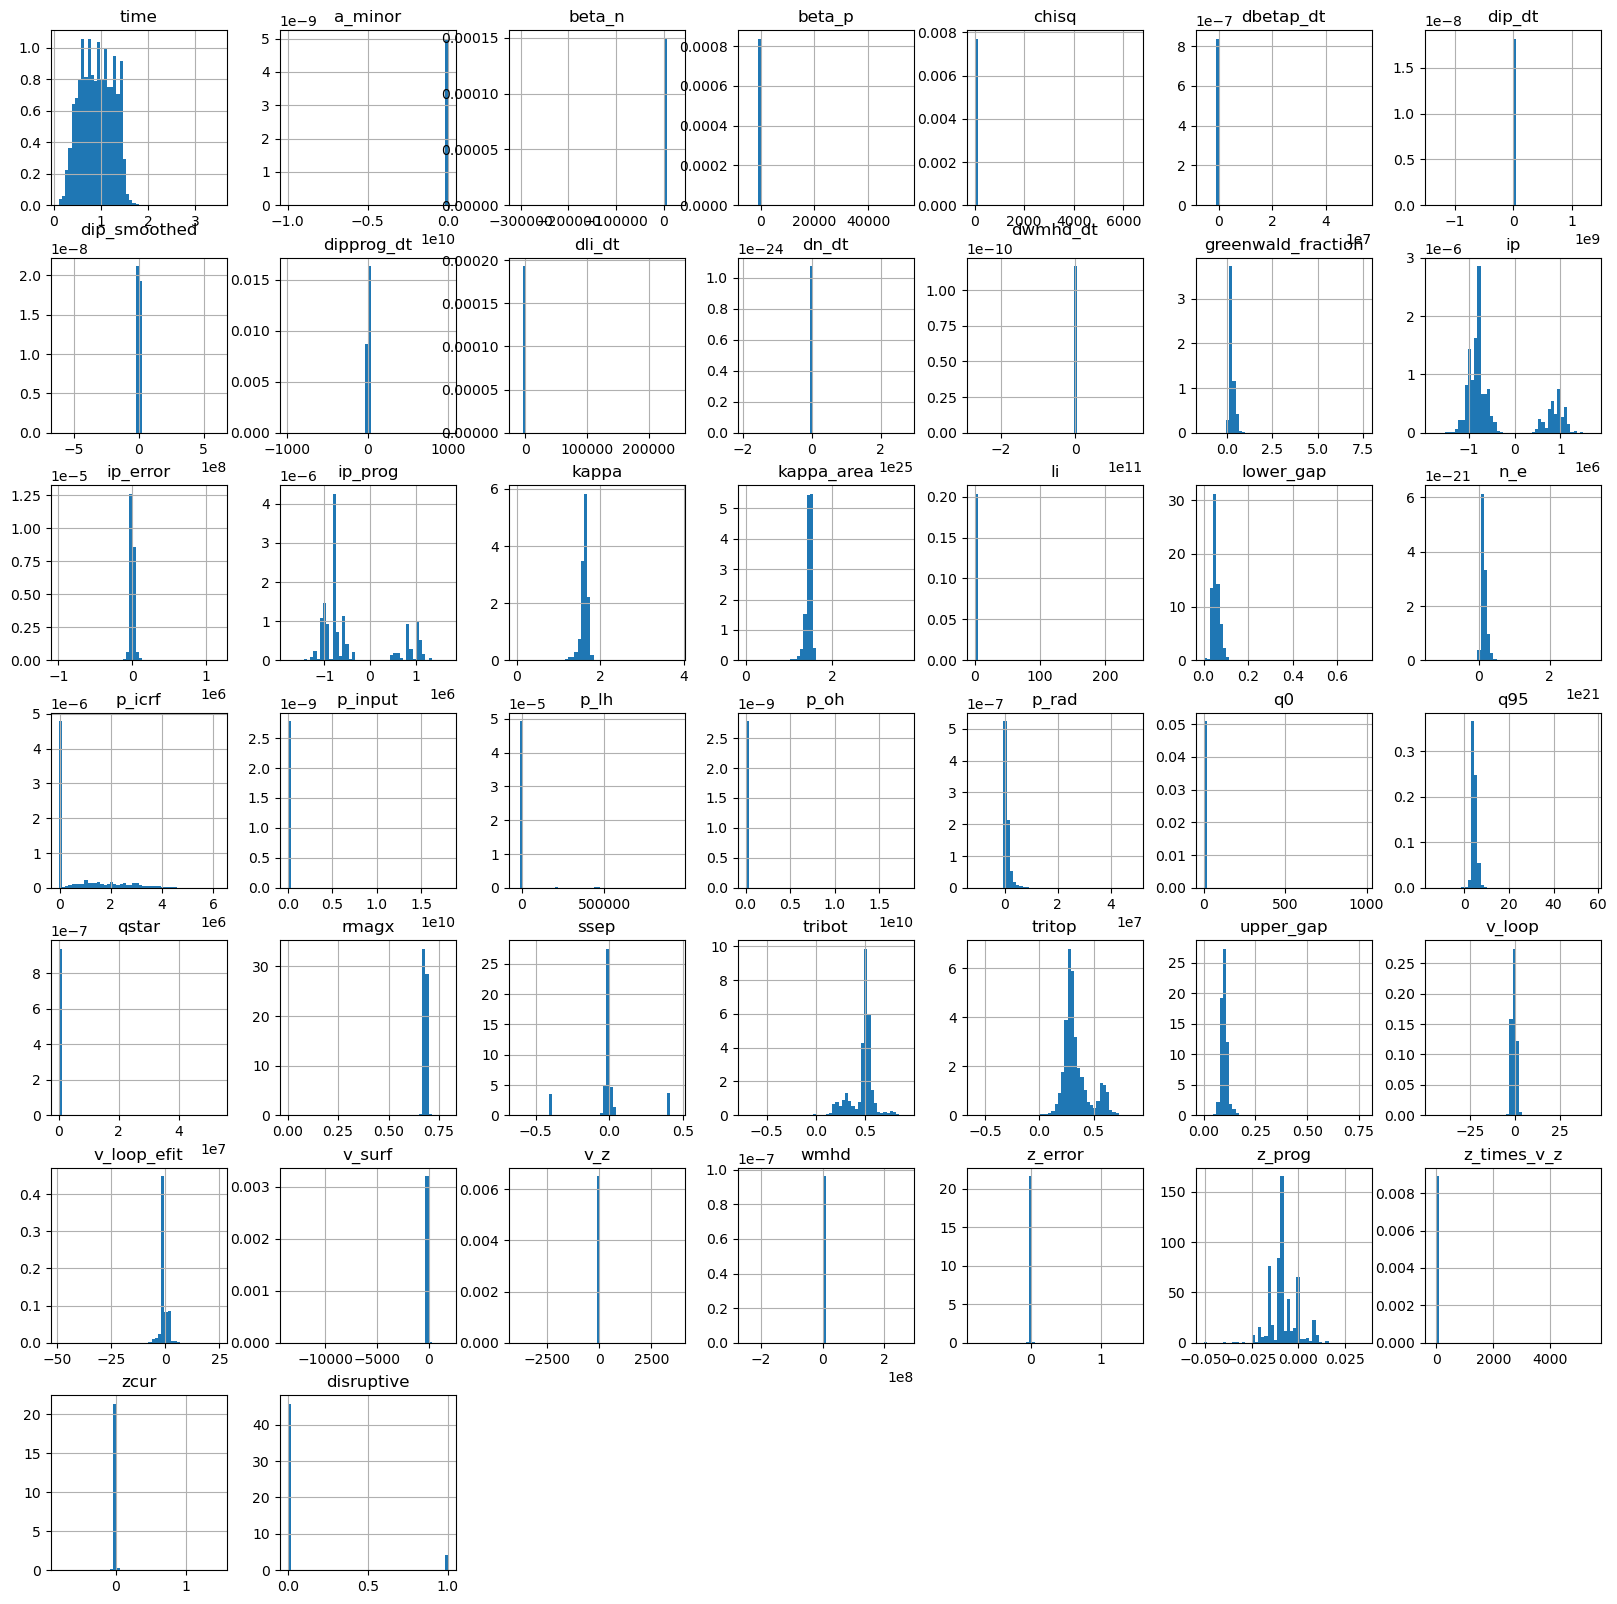

In [10]:
df_classification.hist(figsize=(20,20),bins=50,density=True)

In [11]:
n = len(sequences)
idx = np.random.permutation(n)
sequences, labels = sequences[idx], labels[idx]

n_train = int(0.7 * n)
n_val   = int(0.15 * n)

x_train, y_train = sequences[:n_train], labels[:n_train]
x_val,   y_val   = sequences[n_train:n_train+n_val], labels[n_train:n_train+n_val]
x_test,  y_test  = sequences[n_train+n_val:], labels[n_train+n_val:]

# Scale per-feature across all timesteps
# Fit on (num_train_shots * 50, num_features)
scaler = MinMaxScaler(feature_range=(-1, 1))
x_train_2d = x_train.reshape(-1, x_train.shape[-1])
scaler.fit(x_train_2d)

def scale_seqs(x):
    shape = x.shape
    return scaler.transform(x.reshape(-1, shape[-1])).reshape(shape)

x_train = scale_seqs(x_train)
x_val   = scale_seqs(x_val)
x_test  = scale_seqs(x_test)

print("Train:", x_train.shape, y_train.shape)

Train: (7386, 50, 43) (7386,)


In [12]:
feature_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit on training data only (best practice)
feature_scaler.fit(train_x.astype('float32'))

x_train_scaled = feature_scaler.transform(train_x.astype('float32'))
x_val_scaled = feature_scaler.transform(val_x.astype('float32'))
x_test_scaled = feature_scaler.transform(test_x.astype('float32'))

print("Features")
print("Training:", x_train_scaled.max(), x_train_scaled.min())
print("Validation:", x_val_scaled.max(), x_val_scaled.min())
print("Testing:", x_test_scaled.max(), x_test_scaled.min())

y_train_scaled = train_y.astype('float32')
y_val_scaled = val_y.astype('float32')
y_test_scaled = test_y.astype('float32')

print("\nTargets")
print("Training:", y_train_scaled.max(), y_train_scaled.min())
print("Validation:", y_val_scaled.max(), y_val_scaled.min())
print("Testing:", y_test_scaled.max(), y_test_scaled.min())

print("Features shape:", x_train_scaled.shape)

NameError: name 'train_x' is not defined

In [13]:
import torch
import torch.nn as nn
classifier = ShotTransformer(
    num_features=x_train.shape[2],  # x_train is now [num_shots, 50, num_features]
    output_shape=1
)
class ShotTransformer(nn.Module):
    def __init__(self, num_features, output_shape=1,
                 d_model=64, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()

        # Project the feature vector at each timestep into d_model dims
        # Input per token: (num_features,) — one full timestep
        self.input_proj = nn.Linear(num_features, d_model)

        # Learnable positional encoding — one per timestep position (0..49)
        self.pos_embedding = nn.Parameter(torch.randn(1, 50, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.SELU(),
            nn.Linear(128, output_shape),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, 50, num_features)
        x = self.input_proj(x)        # (B, 50, d_model)
        x = x + self.pos_embedding    # add positional info
        x = self.transformer(x)       # (B, 50, d_model)
        x = x[:, -1, :]              # take the LAST timestep (closest to disruption)
        return self.classifier(x)     # (B, 1)

NameError: name 'ShotTransformer' is not defined

In [ ]:
classifier = ShotTransformer(
    num_features=x_train.shape[2],  # x_train is now [num_shots, 50, num_features]
    output_shape=1
)

In [ ]:
classifier(torch.tensor(x_train[:3]).float())

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train.reshape(-1, 1)))
val_dataset   = TensorDataset(torch.tensor(x_val),   torch.tensor(y_val.reshape(-1, 1)))
test_dataset  = TensorDataset(torch.tensor(x_test),  torch.tensor(y_test.reshape(-1, 1)))

print(train_dataset.tensors[0].shape)  # should be (num_shots, 50, num_features)

In [ ]:
train_dataset.__getitem__(0)

In [ ]:
!nvidia-smi

In [ ]:
config = {
    "seed": 8,
    "name": "ShotTransformer",
    "run_val": 1,
    "model": {
        "input_shape": x_train.shape[-1],  # num_features
        "output_shape": 1,
    },
    "optimizer": {"lr": 7e-4},
    "num_epochs": 20,
    "dataloader": {
        "train": {"batch_size": 64},
        "val":   {"batch_size": 64},
        "test":  {"batch_size": 64},
    },
    "output": {"dir": "./"}
}

In [ ]:
import os
import json
import random
import pkbar
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

def trainer(config, train_dataset, val_dataset, test_dataset):
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    random.seed(config['seed'])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.manual_seed(config['seed'])

    exp_name = config['name']
    print(exp_name)

    output_folder = config['output']['dir']
    output_path = os.path.join(output_folder, exp_name)
    os.makedirs(output_path, exist_ok=True)

    with open(os.path.join(output_path, 'config.json'), 'w') as outfile:
        json.dump(config, outfile)

    print('Creating Loaders.')

    train_batch_size = config['dataloader']['train']['batch_size']
    val_batch_size   = config['dataloader']['val']['batch_size']
    test_batch_size  = config['dataloader']['test']['batch_size']

    # Fix 1: replace CreateLoaders with DataLoader directly
    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=val_batch_size,   shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=test_batch_size,  shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    print("Training Size:",   len(train_loader.dataset))
    print("Validation Size:", len(val_loader.dataset))

    # Fix 2: get output_shape from config, not undefined variable
    num_features = train_dataset.tensors[0].shape[2]
    output_shape = config['model']['output_shape']

    net = ShotTransformer(num_features=num_features, output_shape=output_shape)

    t_params = sum(p.numel() for p in net.parameters())
    print("Network Parameters:", t_params)

    net.to(device)

    num_epochs = int(config['num_epochs'])
    lr = float(config['optimizer']['lr'])

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, net.parameters()), lr=lr
    )

    num_steps = len(train_loader) * num_epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer, T_max=num_steps, last_epoch=-1, eta_min=0
    )

    startEpoch  = 0
    global_step = 0

    print('===========  Optimizer  ==================:')
    print('      LR:', lr)
    print('      num_epochs:', num_epochs)
    print('')

    all_train_y = train_dataset.tensors[1].cpu().numpy().astype(int).ravel()
    class_counts  = np.bincount(all_train_y)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_weights)
    pos_weight    = torch.tensor(class_weights[1] / class_weights[0], dtype=torch.float32).to(device)

    loss_function = nn.BCELoss(reduction='none')

    for epoch in range(startEpoch, num_epochs):

        kbar = pkbar.Kbar(
            target=len(train_loader), epoch=epoch,
            num_epochs=num_epochs, width=20, always_stateful=False
        )

        net.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            inputs = data[0].to(device).float()
            y      = data[1].to(device).float().view(-1, 1)

            optimizer.zero_grad()
            y_hat = net(inputs)

            weights = torch.ones_like(y)
            weights[y == 1] = pos_weight

            loss = (loss_function(y_hat, y) * weights).mean()
            train_acc = (torch.round(y_hat) == y).float().mean().item()

            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * inputs.shape[0]
            kbar.update(i, values=[("loss", loss.item()), ("train_acc", train_acc)])
            global_step += 1

        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['lr'].append(scheduler.get_last_lr()[0])

        if bool(config['run_val']):
            net.eval()
            val_loss = 0.0
            val_acc  = 0.0

            with torch.no_grad():
                for i, data in enumerate(val_loader):
                    inputs = data[0].to(device).float()
                    y      = data[1].to(device).float().view(-1, 1)
                    y_hat  = net(inputs)

                    weights = torch.ones_like(y)
                    weights[y == 1] = pos_weight

                    loss = (loss_function(y_hat, y) * weights).mean()
                    val_acc  += (torch.round(y_hat) == y).float().mean().item()
                    val_loss += loss.item()

            val_loss = val_loss / len(val_loader)
            val_acc  = val_acc  / len(val_loader)
            history['val_loss'].append(val_loss)

            kbar.add(1, values=[("val_loss", val_loss), ("val_acc", val_acc)])
            name_output_file = config['name'] + '_epoch{:02d}_val_loss_{:.6f}.pth'.format(epoch, val_loss)
        else:
            kbar.add(1, values=[('val_loss', 0.)])
            name_output_file = config['name'] + '_epoch{:02d}_train_loss_{:.6f}.pth'.format(epoch, history['train_loss'][-1])

        checkpoint = {
            'net_state_dict': net.state_dict(),
            'optimizer':      optimizer.state_dict(),
            'scheduler':      scheduler.state_dict(),
            'epoch':          epoch,
            'history':        history,
            'global_step':    global_step,
        }
        torch.save(checkpoint, os.path.join(output_path, name_output_file))
        print('')

    return net, history

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [ ]:
trainer(config,train_dataset,val_dataset,test_dataset)

In [ ]:
checkpoint_dir = os.path.join(config['output']['dir'], config['name'])

pth_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]
latest_file = sorted(pth_files)[-1]

dicte = torch.load(
    os.path.join(checkpoint_dir, latest_file),
    map_location="cpu"
)

print(dicte.keys())

In [ ]:
import matplotlib.pyplot as plt

train_loss = dicte['history']['train_loss']
val_loss = dicte['history']['val_loss']
learning_rate = dicte['history']['lr']

plt.plot(train_loss,'r-',label="Training Loss")
plt.plot(val_loss,'b-',label='Validation Loss')
plt.legend(fontsize=15)
plt.xlabel('Epoch',fontsize=15)
plt.ylabel('Loss',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.show()

plt.plot(learning_rate,'k-',label=r"Learning Rate - $\eta$")
plt.legend(fontsize=15)
plt.xlabel('Epoch',fontsize=15)
plt.ylabel(r'$\eta$',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.show()

In [ ]:
config['model']['input_shape'] = x_train.shape[2]  # shape[2] = 43 (features), correct
input_shape = config['model']['input_shape']
output_shape = config['model']['output_shape']

net = ShotTransformer(num_features=input_shape, output_shape=output_shape)

t_params = sum(p.numel() for p in net.parameters())
print("Network Parameters:", t_params)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

checkpoint_dir = os.path.join(config['output']['dir'], config['name'])
pth_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]
latest_file = sorted(pth_files)[-1]

dicte = torch.load(
    os.path.join(checkpoint_dir, latest_file),
    map_location=device,
    weights_only=False
)

net.load_state_dict(dicte["net_state_dict"])
net.eval()

In [ ]:
test_loader = DataLoader(test_dataset,batch_size=config['dataloader']['test']['batch_size'])
net.eval() # Eval mode

predictions = []
y_true = []
kbar = pkbar.Kbar(target=len(test_loader), width=20, always_stateful=False)
for i,data in enumerate(test_loader):
    x = data[0].to('cuda').float()
    y_true.append(data[1].numpy())

    with torch.set_grad_enabled(False): # Same as with torch.no_grad():
        y_hat = net(x).detach().cpu().numpy()

    predictions.append(y_hat)

    kbar.update(i)

predictions = np.concatenate(predictions)
y_true = np.concatenate(y_true)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, predictions)

# Calculate the AUC (Area Under the Curve)
auc = roc_auc_score(y_true, predictions)
print(f"AUC: {auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

cm = confusion_matrix(y_true, predictions.round())
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")